# 📈 Hull Tactical Market Prediction — ML Notebook

**Objective:** Predict `forward_returns` (next-period stock returns) using a rich set of engineered market signals (D, E, I, M, P, S, V feature groups).

**Workflow:**
1. Exploratory Data Analysis (EDA)
2. Feature Engineering & Selection
3. Model Training — Linear Baseline, Random Forest, LightGBM
4. Evaluation — IC, Sharpe, RMSE, Feature Importance
5. Final Insights

> Dataset: `train.csv` — 9 048 daily observations, 97 features + target


In [1]:
import warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

import lightgbm as lgb
from scipy.stats import pearsonr, spearmanr

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 30)

DATA_DIR = os.path.dirname(os.path.abspath("train.csv")) if os.path.exists("train.csv") else "."
print("✅ Libraries loaded successfully")
print(f"📂 Working directory: {os.getcwd()}")


✅ Libraries loaded successfully
📂 Working directory: /home/claude/market_pred


## 1. Load & Inspect Data

In [2]:
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}")
print(f"\nDate range  : {train['date_id'].min()} → {train['date_id'].max()}")
print(f"\nTarget — forward_returns")
print(train['forward_returns'].describe().round(6))
train.head(3)


Train shape : (9048, 98)
Test  shape : (10, 99)

Date range  : 0 → 9047

Target — forward_returns
count   9048.0000
mean       0.0005
std        0.0105
min       -0.0398
25%       -0.0043
50%        0.0007
75%        0.0059
max        0.0407
Name: forward_returns, dtype: float64


,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,E10,E11,E12,E13,...,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
0,0,0,0,0,1,1,0,0,0,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0024,0.0003,-0.0030
1,1,0,0,0,1,1,0,0,0,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0085,0.0003,-0.0091
2,2,0,0,0,1,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0096,0.0003,-0.0102


### Missing Value Analysis

                   Group  Num Features  Missing %
D (Day-of-week/calendar)             9     0.0000
    E (Economic signals)            20    15.2000
       I (Index signals)             9    11.1000
    M (Momentum signals)            18    25.3000
         P (Price-based)            13    12.7000
  S (Statistical/spread)            12    20.1000
   V (Volume/volatility)            13    19.7000


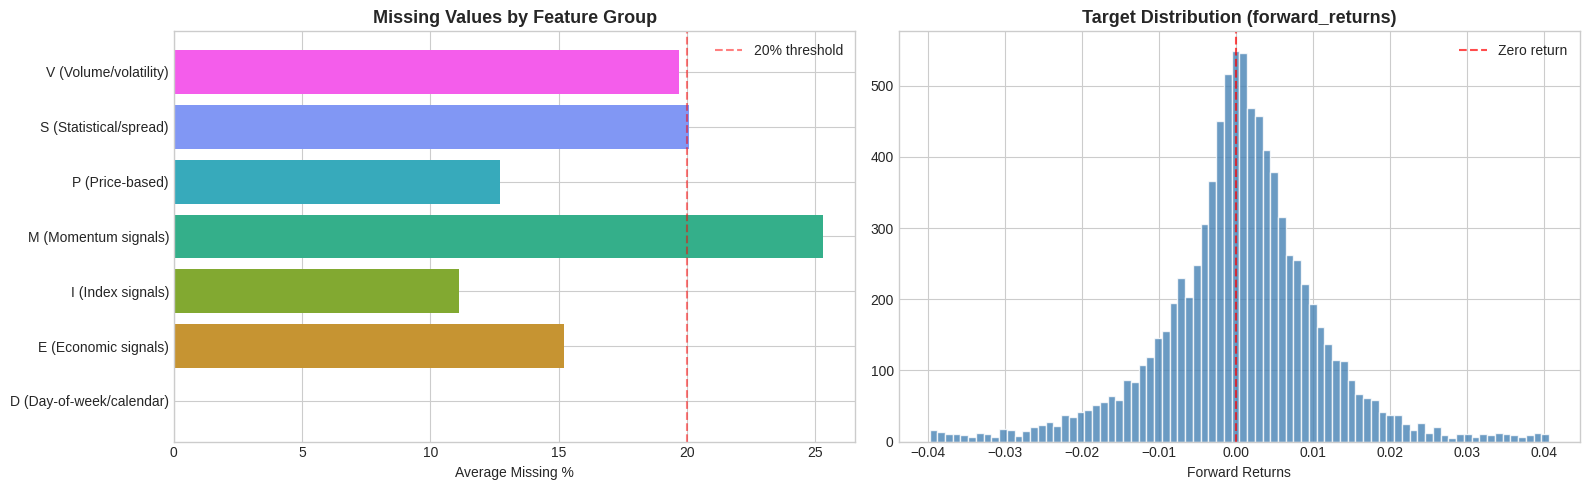

✅ EDA overview saved


In [3]:
FEATURE_GROUPS = {
    'D (Day-of-week/calendar)': [c for c in train.columns if c.startswith('D')],
    'E (Economic signals)':     [c for c in train.columns if c.startswith('E')],
    'I (Index signals)':        [c for c in train.columns if c.startswith('I')],
    'M (Momentum signals)':     [c for c in train.columns if c.startswith('M')],
    'P (Price-based)':          [c for c in train.columns if c.startswith('P')],
    'S (Statistical/spread)':   [c for c in train.columns if c.startswith('S')],
    'V (Volume/volatility)':    [c for c in train.columns if c.startswith('V')],
}

miss_summary = []
for grp, cols in FEATURE_GROUPS.items():
    miss_pct = train[cols].isnull().mean().mean() * 100
    miss_summary.append({'Group': grp, 'Num Features': len(cols), 'Missing %': round(miss_pct, 1)})

miss_df = pd.DataFrame(miss_summary)
print(miss_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Missing heatmap by group
axes[0].barh(miss_df['Group'], miss_df['Missing %'], color=sns.color_palette("husl", 7))
axes[0].set_xlabel('Average Missing %')
axes[0].set_title('Missing Values by Feature Group', fontsize=13, fontweight='bold')
axes[0].axvline(20, color='red', linestyle='--', alpha=0.5, label='20% threshold')
axes[0].legend()

# Target distribution
axes[1].hist(train['forward_returns'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7, label='Zero return')
axes[1].set_xlabel('Forward Returns')
axes[1].set_title('Target Distribution (forward_returns)', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('01_eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ EDA overview saved")


### Target Over Time & Rolling Statistics

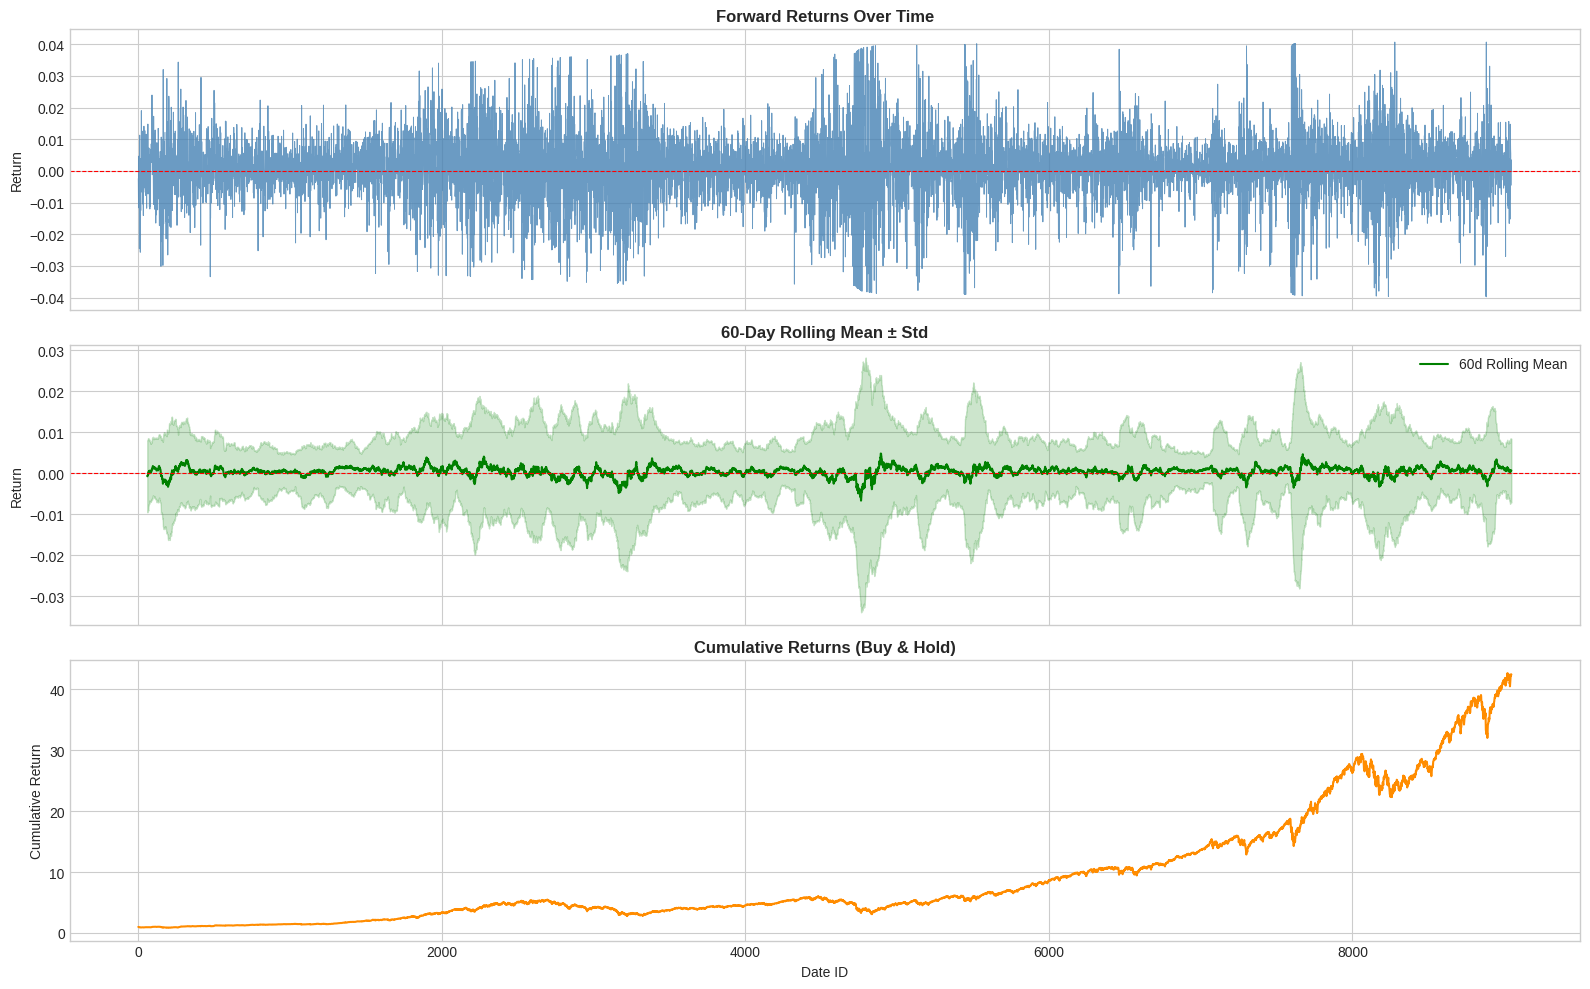

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

axes[0].plot(train['date_id'], train['forward_returns'], lw=0.7, color='steelblue', alpha=0.8)
axes[0].set_title('Forward Returns Over Time', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Return')
axes[0].axhline(0, color='red', linestyle='--', lw=0.8)

roll = train['forward_returns'].rolling(60)
axes[1].plot(train['date_id'], roll.mean(), color='green', lw=1.5, label='60d Rolling Mean')
axes[1].fill_between(train['date_id'],
                     roll.mean() - roll.std(),
                     roll.mean() + roll.std(),
                     alpha=0.2, color='green')
axes[1].set_title('60-Day Rolling Mean ± Std', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Return')
axes[1].legend()
axes[1].axhline(0, color='red', linestyle='--', lw=0.8)

# Cumulative return
cum = (1 + train['forward_returns']).cumprod()
axes[2].plot(train['date_id'], cum, color='darkorange', lw=1.5)
axes[2].set_title('Cumulative Returns (Buy & Hold)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Cumulative Return')
axes[2].set_xlabel('Date ID')

plt.tight_layout()
plt.savefig('02_target_over_time.png', dpi=120, bbox_inches='tight')
plt.show()


## 2. Feature Engineering

We build a cleaned, enriched feature matrix:
- **Impute** missing values using forward-fill then median fallback  
- **Lag features** — rolling 5-day and 20-day mean of key signal groups  
- **Interaction** — momentum × volatility cross-signal  
- **Excess return target** — subtract risk-free rate for cleaner signal


In [5]:
def build_features(df, is_train=True, fit_medians=None):
    df = df.copy().sort_values('date_id').reset_index(drop=True)
    
    feature_cols = [c for c in df.columns 
                    if c not in ['date_id','forward_returns','risk_free_rate',
                                 'market_forward_excess_returns']]
    
    # --- Imputation: forward fill then median ---
    if is_train:
        fit_medians = df[feature_cols].median()
    
    df[feature_cols] = df[feature_cols].ffill().fillna(fit_medians)
    
    # --- Rolling lag features (5d & 20d) ---
    key_signals = (
        [c for c in df.columns if c.startswith('M')][:5] +
        [c for c in df.columns if c.startswith('V')][:5] +
        [c for c in df.columns if c.startswith('S')][:3]
    )
    for col in key_signals:
        df[f'{col}_roll5']  = df[col].rolling(5,  min_periods=1).mean()
        df[f'{col}_roll20'] = df[col].rolling(20, min_periods=1).mean()
        df[f'{col}_std5']   = df[col].rolling(5,  min_periods=1).std().fillna(0)
    
    # --- Interaction: momentum × volatility ---
    m_cols = [c for c in df.columns if c.startswith('M')][:3]
    v_cols = [c for c in df.columns if c.startswith('V')][:3]
    for m, v in zip(m_cols, v_cols):
        df[f'MV_cross_{m}_{v}'] = df[m] * df[v]
    
    # --- Excess return target (only for train) ---
    if is_train:
        df['excess_return'] = df['forward_returns'] - df['risk_free_rate']
    
    return df, fit_medians

train_fe, medians = build_features(train, is_train=True)
test_fe,  _       = build_features(test,  is_train=False, fit_medians=medians)

all_feat_cols = [c for c in train_fe.columns 
                 if c not in ['date_id','forward_returns','risk_free_rate',
                               'market_forward_excess_returns','excess_return']]

X = train_fe[all_feat_cols]
y = train_fe['forward_returns']
y_excess = train_fe['excess_return']

print(f"Feature matrix X : {X.shape}")
print(f"Target y         : {y.shape}")
print(f"  Mean={y.mean():.5f}  Std={y.std():.5f}  Skew={y.skew():.3f}")


Feature matrix X : (9048, 136)
Target y         : (9048,)
  Mean=0.00047  Std=0.01053  Skew=-0.178


## 3. Feature Selection

Three complementary methods:
1. **Correlation / IC** — Pearson & Spearman with target  
2. **F-regression** — Univariate ANOVA F-score  
3. **Mutual Information** — Non-linear dependence  

Features scoring consistently across methods are prioritised.


In [6]:
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

# 1. Correlation-based IC
pearson_corr  = X.corrwith(y, method='pearson').abs().rename('pearson_abs')
spearman_corr = X.corrwith(y, method='spearman').abs().rename('spearman_abs')

# 2. F-regression
selector_f   = SelectKBest(f_regression, k='all')
selector_f.fit(X, y)
f_scores = pd.Series(selector_f.scores_, index=X.columns, name='f_score')

# 3. Mutual information (subsample for speed)
rng = np.random.default_rng(42)
idx = rng.choice(len(X), size=min(3000, len(X)), replace=False)
mi_scores = pd.Series(
    mutual_info_regression(X.iloc[idx], y.iloc[idx], random_state=42),
    index=X.columns, name='mutual_info'
)

# Combine & rank
selection_df = pd.concat([pearson_corr, spearman_corr, f_scores, mi_scores], axis=1)

# Normalise each metric 0-1 then average
for col in selection_df.columns:
    rng_val = selection_df[col].max() - selection_df[col].min()
    selection_df[f'{col}_norm'] = (selection_df[col] - selection_df[col].min()) / (rng_val + 1e-9)

norm_cols = [c for c in selection_df.columns if c.endswith('_norm')]
selection_df['composite_score'] = selection_df[norm_cols].mean(axis=1)
selection_df = selection_df.sort_values('composite_score', ascending=False)

TOP_K = 40
top_features = selection_df.head(TOP_K).index.tolist()
print(f"Top {TOP_K} features selected by composite score")
print("\nTop 15 features:")
print(selection_df[['pearson_abs','spearman_abs','mutual_info','composite_score']].head(15).round(4))


Top 40 features selected by composite score

Top 15 features:
            pearson_abs  spearman_abs  mutual_info  composite_score
M4               0.0647        0.0483       0.0536           0.8857
V13              0.0600        0.0407       0.0567           0.8011
V7               0.0314        0.0315       0.0988           0.5922
S5               0.0388        0.0361       0.0644           0.5885
S2               0.0371        0.0406       0.0538           0.5706
V13_roll5        0.0309        0.0367       0.0716           0.5472
E19              0.0245        0.0331       0.0870           0.5210
P5               0.0223        0.0365       0.0755           0.4950
M17              0.0242        0.0252       0.0627           0.4164
V13_std5         0.0074        0.0308       0.0817           0.3969
P8               0.0254        0.0196       0.0606           0.3899
M1_roll5         0.0245        0.0334       0.0340           0.3883
M8               0.0237        0.0231       0.0554    

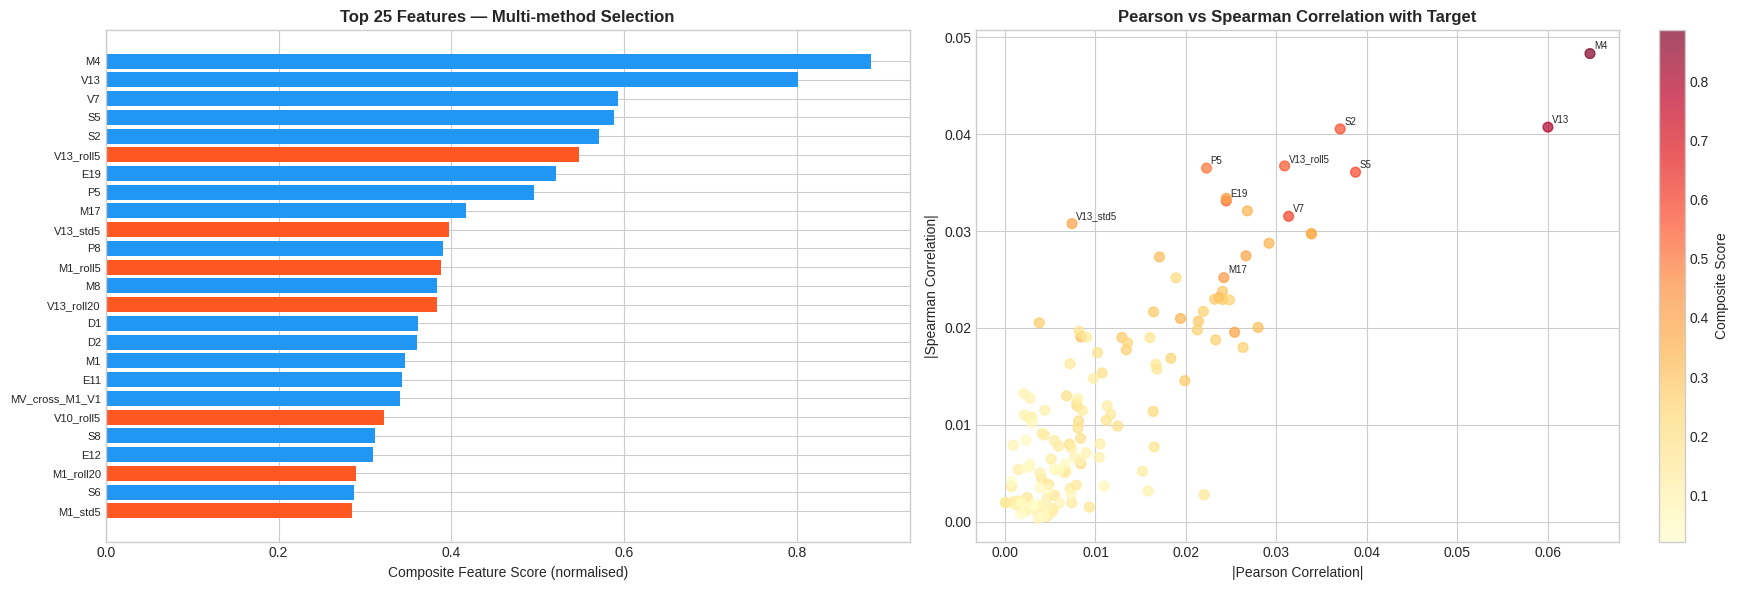

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar plot of top 25 by composite score
top25 = selection_df.head(25)
colors = ['#2196F3' if not c.endswith(('roll5','roll20','std5')) else '#FF5722'
          for c in top25.index]
axes[0].barh(top25.index[::-1], top25['composite_score'][::-1], color=colors[::-1])
axes[0].set_xlabel('Composite Feature Score (normalised)')
axes[0].set_title('Top 25 Features — Multi-method Selection', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='y', labelsize=8)

# Score scatter: Pearson vs Spearman
axes[1].scatter(selection_df['pearson_abs'], selection_df['spearman_abs'],
                c=selection_df['composite_score'], cmap='YlOrRd', s=50, alpha=0.7)
top_pts = selection_df.head(10)
for feat in top_pts.index:
    axes[1].annotate(feat, (top_pts.loc[feat,'pearson_abs'], top_pts.loc[feat,'spearman_abs']),
                     fontsize=7, xytext=(3,3), textcoords='offset points')
axes[1].set_xlabel('|Pearson Correlation|')
axes[1].set_ylabel('|Spearman Correlation|')
axes[1].set_title('Pearson vs Spearman Correlation with Target', fontsize=12, fontweight='bold')
plt.colorbar(axes[1].collections[0], ax=axes[1], label='Composite Score')

plt.tight_layout()
plt.savefig('03_feature_selection.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. Model Training

We use **TimeSeriesSplit** (no look-ahead leakage) with 5 folds.

Models:
| Model | Why? |
|-------|------|
| **Ridge Regression** | Linear baseline, handles multicollinearity |
| **Lasso Regression** | Sparse linear model, auto feature selection |
| **Random Forest** | Non-linear, robust to outliers |
| **LightGBM** | State-of-the-art gradient boosting for tabular data |


In [8]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import make_scorer

# Custom scorer: Information Coefficient (Spearman rank correlation)
def ic_scorer(estimator, X_, y_):
    pred = estimator.predict(X_)
    ic, _ = spearmanr(pred, y_)
    return ic if not np.isnan(ic) else 0.0

ic_score = make_scorer(ic_scorer)

# ── Data split ──────────────────────────────────────────────────────────────
X_sel = X[top_features]
tscv  = TimeSeriesSplit(n_splits=5)

# Hold-out: last 20% for final evaluation
split_idx = int(len(X_sel) * 0.8)
X_tr, X_val = X_sel.iloc[:split_idx], X_sel.iloc[split_idx:]
y_tr, y_val = y.iloc[:split_idx],     y.iloc[split_idx:]

print(f"Train : {X_tr.shape[0]} rows  |  Val : {X_val.shape[0]} rows")
print(f"Selected features : {X_sel.shape[1]}")


Train : 7238 rows  |  Val : 1810 rows
Selected features : 40


In [9]:
# ── Define models ────────────────────────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=10.0))
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.0001, max_iter=5000))
    ]),
    'RandomForest': RandomForestRegressor(
        n_estimators=200, max_depth=6, min_samples_leaf=20,
        n_jobs=-1, random_state=42
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.02, num_leaves=31,
        max_depth=5, min_child_samples=30, subsample=0.8,
        colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1,
        random_state=42, verbose=-1
    )
}

# ── Cross-validation ─────────────────────────────────────────────────────────
cv_results = {}
print("Training with TimeSeriesSplit (5 folds)…\n")
for name, model in models.items():
    cv = cross_validate(
        model, X_tr, y_tr, cv=tscv,
        scoring={'neg_rmse': 'neg_root_mean_squared_error',
                 'r2': 'r2',
                 'ic': ic_score},
        return_train_score=False
    )
    cv_results[name] = {
        'CV RMSE': -cv['test_neg_rmse'].mean(),
        'CV RMSE std': cv['test_neg_rmse'].std(),
        'CV R²': cv['test_r2'].mean(),
        'CV IC': cv['test_ic'].mean(),
    }
    print(f"  {name:15s}  RMSE={-cv['test_neg_rmse'].mean():.6f}"
          f"  R²={cv['test_r2'].mean():.4f}"
          f"  IC={cv['test_ic'].mean():.4f}")

cv_df = pd.DataFrame(cv_results).T.round(6)
print("\n─── Cross-Validation Summary ───")
print(cv_df)


Training with TimeSeriesSplit (5 folds)…

  Ridge            RMSE=0.012846  R²=-0.6220  IC=nan
  Lasso            RMSE=0.010736  R²=-0.0083  IC=nan


  RandomForest     RMSE=0.010738  R²=-0.0090  IC=nan


  LightGBM         RMSE=0.011166  R²=-0.0919  IC=nan

─── Cross-Validation Summary ───
              CV RMSE  CV RMSE std   CV R²  CV IC
Ridge          0.0128       0.0040 -0.6220    NaN
Lasso          0.0107       0.0018 -0.0083    NaN
RandomForest   0.0107       0.0018 -0.0090    NaN
LightGBM       0.0112       0.0020 -0.0919    NaN


## 5. Evaluation on Hold-out Set

In [10]:
# Fit all models on full training data, evaluate on hold-out
holdout_results = {}
trained_models  = {}

for name, model in models.items():
    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2   = r2_score(y_val, preds)
    ic_p, _ = pearsonr(preds, y_val)
    ic_s, _ = spearmanr(preds, y_val)
    
    # Directional accuracy
    dir_acc = np.mean(np.sign(preds) == np.sign(y_val))
    
    # Sharpe of long/short strategy (long when pred>0, short when pred<0)
    strategy_ret = np.where(preds > 0, y_val, -y_val)
    sharpe = strategy_ret.mean() / (strategy_ret.std() + 1e-9) * np.sqrt(252)
    
    holdout_results[name] = {
        'RMSE': rmse, 'R²': r2,
        'IC (Pearson)': ic_p, 'IC (Spearman)': ic_s,
        'Directional Acc': dir_acc, 'Ann. Sharpe': sharpe
    }
    trained_models[name] = (model, preds)

holdout_df = pd.DataFrame(holdout_results).T.round(4)
print("─── Hold-Out Evaluation ───")
print(holdout_df)


─── Hold-Out Evaluation ───
               RMSE      R²  IC (Pearson)  IC (Spearman)  Directional Acc  \
Ridge        0.0113 -0.0304        0.0526         0.0515           0.5116   
Lasso        0.0111 -0.0046        0.0420         0.0336           0.5077   
RandomForest 0.0112 -0.0163        0.0022         0.0203           0.5271   
LightGBM     0.0115 -0.0750        0.0195         0.0380           0.5105   

              Ann. Sharpe  
Ridge              0.4386  
Lasso              0.1319  
RandomForest       0.2945  
LightGBM           0.2265  


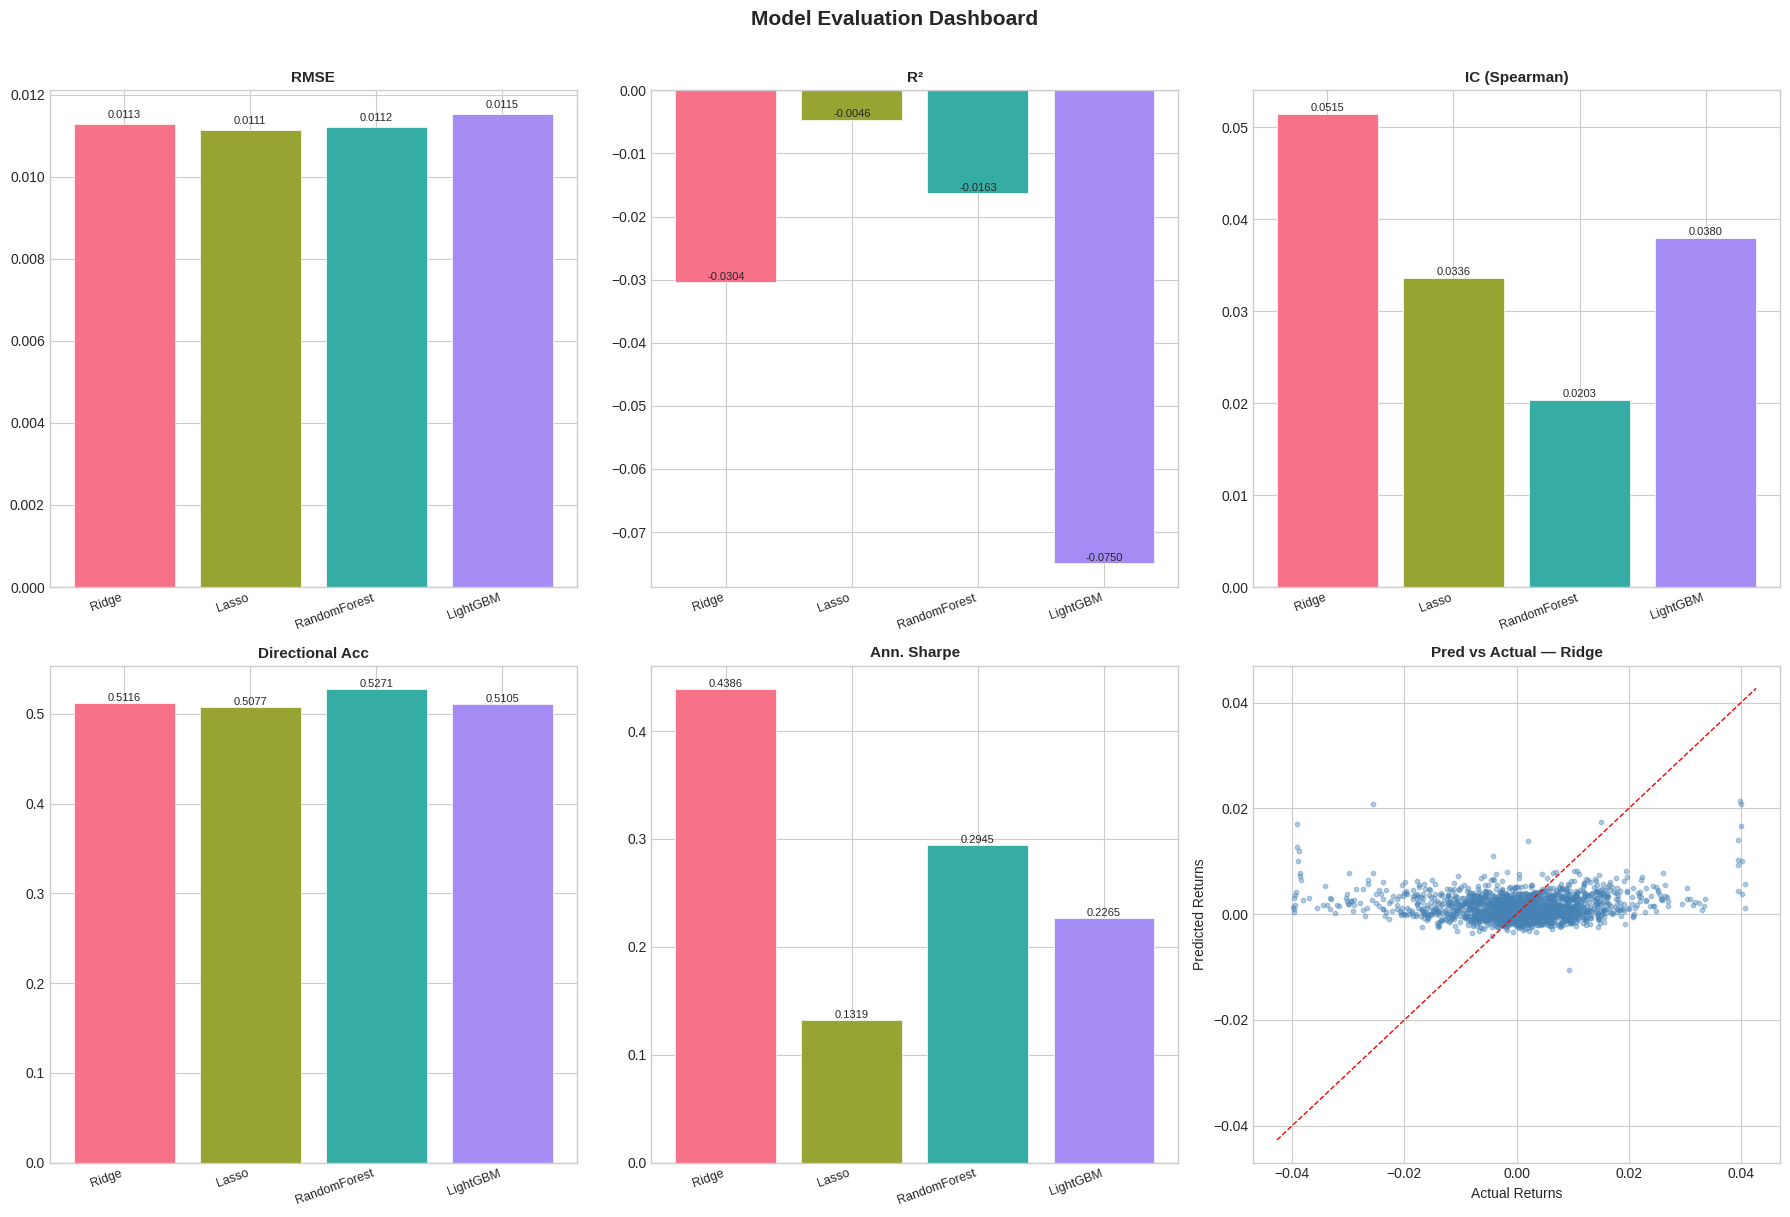


🏆 Best model by IC (Spearman): Ridge


In [11]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig)

model_names = list(holdout_results.keys())
colors      = sns.color_palette("husl", len(model_names))

# ── Bar plots for metrics ────────────────────────────────────────────────────
metrics = ['RMSE','R²','IC (Spearman)','Directional Acc','Ann. Sharpe']
axes_meta = [fig.add_subplot(gs[0, i]) for i in range(3)] + [fig.add_subplot(gs[1, i]) for i in range(2)]

for ax, metric in zip(axes_meta, metrics):
    vals = [holdout_results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.0001,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8)

# ── Predicted vs Actual scatter for best model ────────────────────────────────
best_model = holdout_df['IC (Spearman)'].idxmax()
_, best_preds = trained_models[best_model]

ax_scatter = fig.add_subplot(gs[1, 2])
ax_scatter.scatter(y_val, best_preds, alpha=0.4, s=10, color='steelblue')
lim = max(abs(y_val).max(), abs(best_preds).max()) * 1.05
ax_scatter.plot([-lim, lim], [-lim, lim], 'r--', lw=1)
ax_scatter.set_xlabel('Actual Returns', fontsize=10)
ax_scatter.set_ylabel('Predicted Returns', fontsize=10)
ax_scatter.set_title(f'Pred vs Actual — {best_model}', fontsize=11, fontweight='bold')

plt.suptitle('Model Evaluation Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('04_evaluation_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\n🏆 Best model by IC (Spearman): {best_model}")


## 6. Feature Importance Analysis

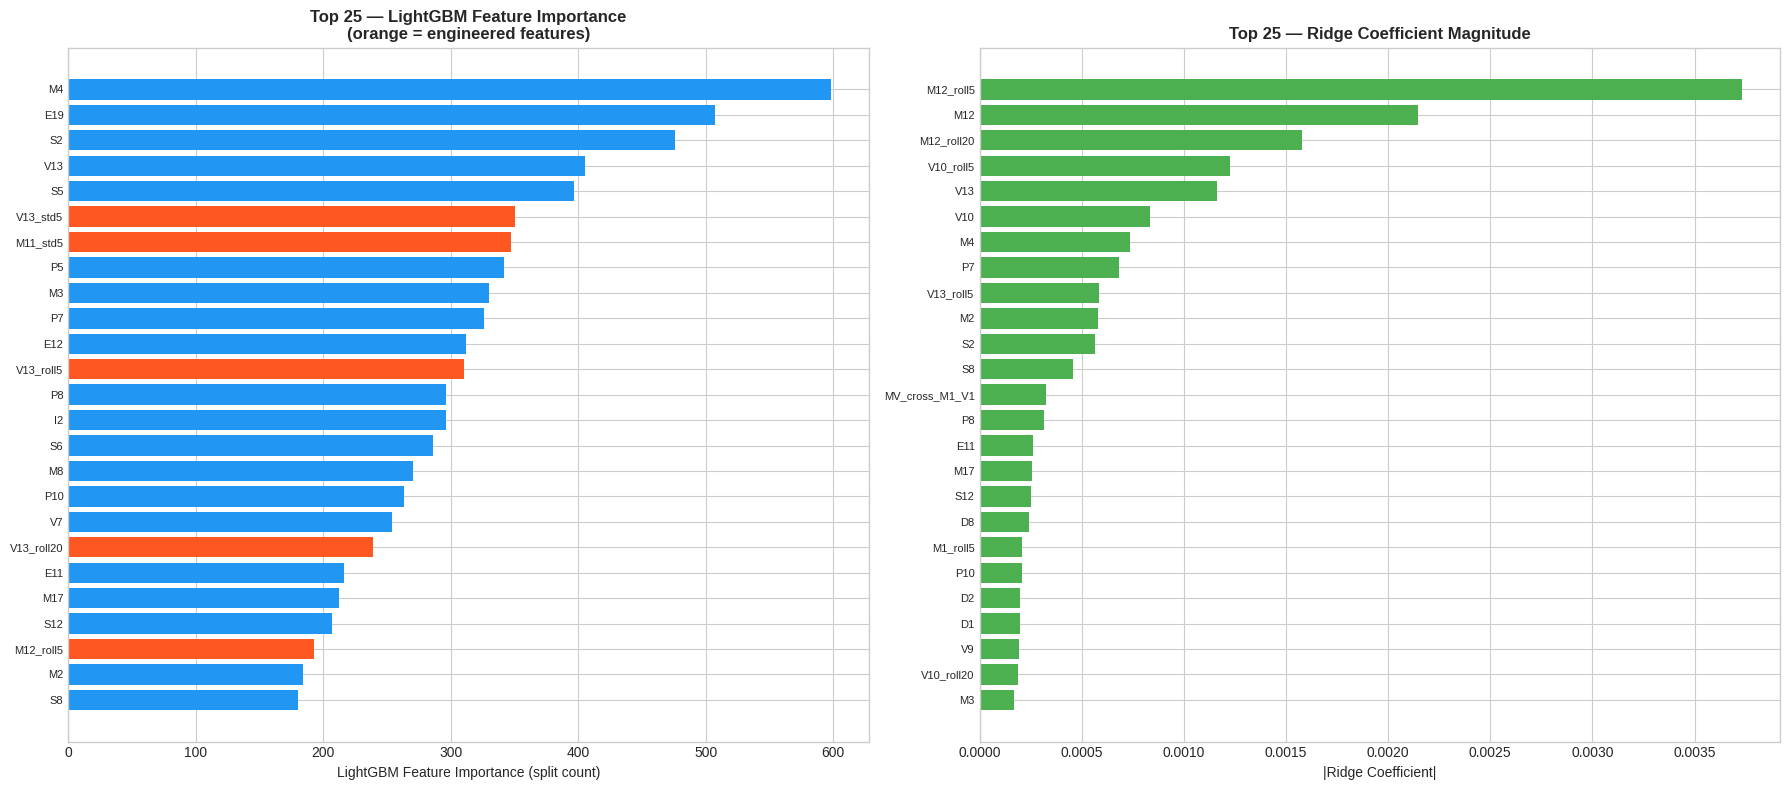


Top 10 LightGBM features:
M4          598
E19         507
S2          476
V13         405
S5          397
V13_std5    350
M11_std5    347
P5          342
M3          330
P7          326
dtype: int32


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ── LightGBM importance ───────────────────────────────────────────────────────
lgbm_model = trained_models['LightGBM'][0]
lgbm_imp = pd.Series(
    lgbm_model.feature_importances_,
    index=top_features
).sort_values(ascending=False)

top_imp = lgbm_imp.head(25)
colors_imp = ['#FF5722' if c.endswith(('roll5','roll20','std5')) else '#2196F3'
              for c in top_imp.index]
axes[0].barh(top_imp.index[::-1], top_imp.values[::-1], color=colors_imp[::-1])
axes[0].set_xlabel('LightGBM Feature Importance (split count)')
axes[0].set_title('Top 25 — LightGBM Feature Importance\n(orange = engineered features)',
                  fontsize=12, fontweight='bold')
axes[0].tick_params(axis='y', labelsize=8)

# ── Ridge coefficient magnitude ───────────────────────────────────────────────
ridge_model = trained_models['Ridge'][0]
ridge_coefs = pd.Series(
    np.abs(ridge_model.named_steps['model'].coef_),
    index=top_features
).sort_values(ascending=False)

top_ridge = ridge_coefs.head(25)
axes[1].barh(top_ridge.index[::-1], top_ridge.values[::-1], color='#4CAF50')
axes[1].set_xlabel('|Ridge Coefficient|')
axes[1].set_title('Top 25 — Ridge Coefficient Magnitude', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('05_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nTop 10 LightGBM features:")
print(lgbm_imp.head(10).round(1))


## 7. Long/Short Strategy Backtest (Hold-out Period)

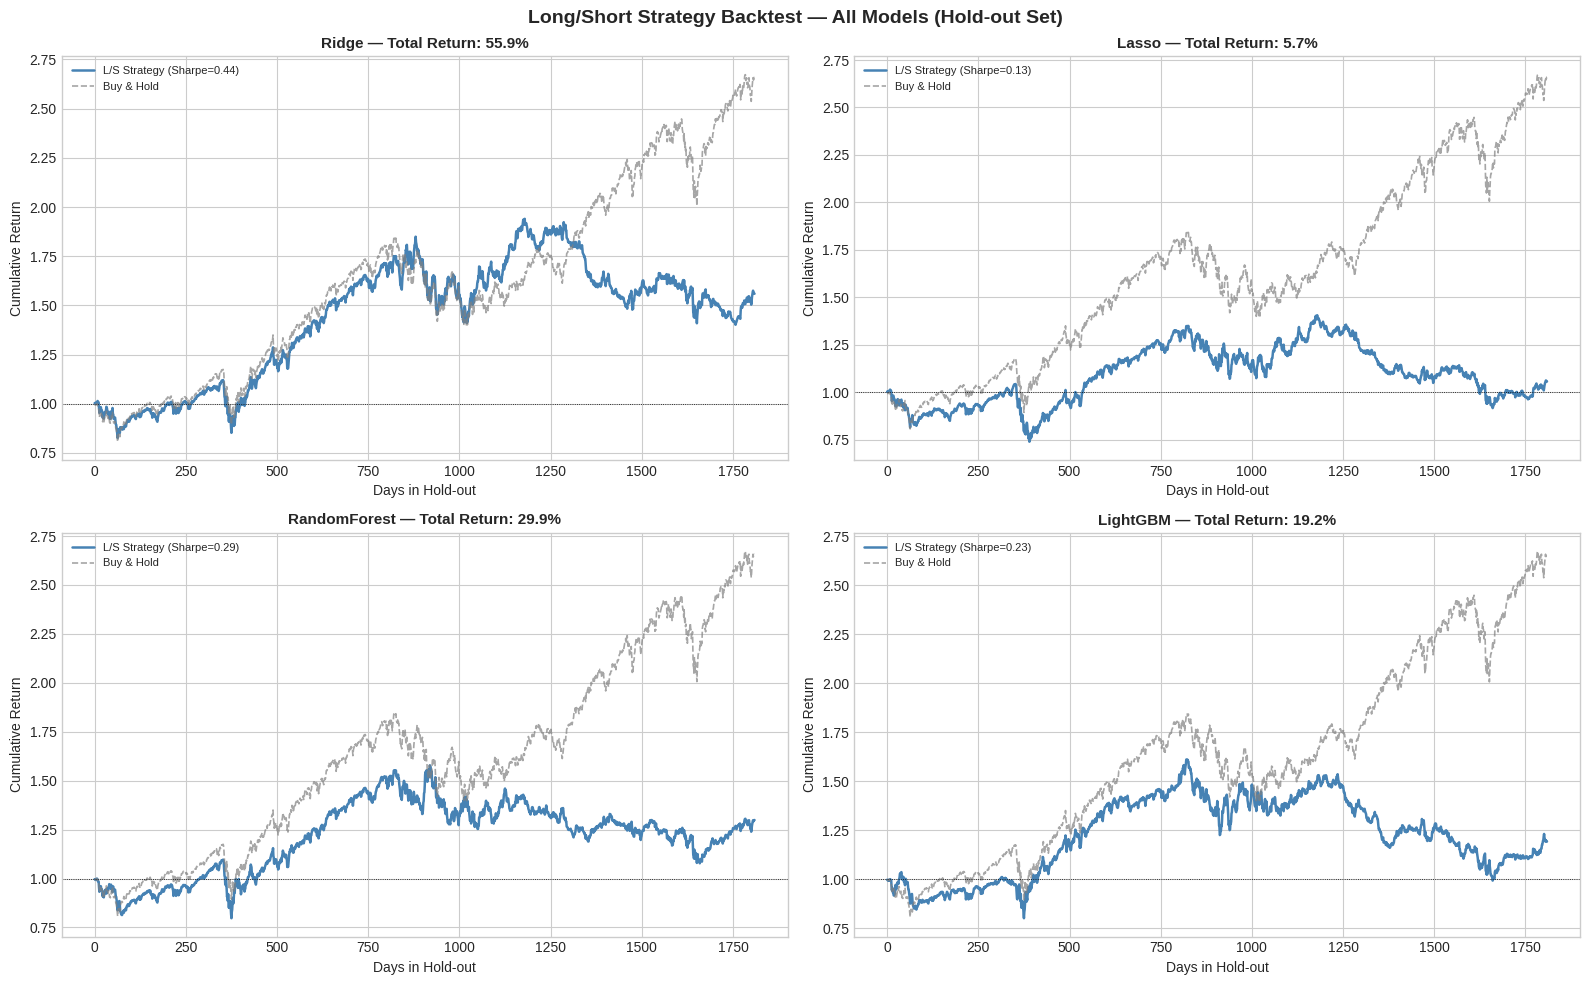

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

val_dates = np.arange(len(y_val))
buy_hold_cum = (1 + y_val.values).cumprod()

for ax, (name, (_, preds)) in zip(axes.flatten(), trained_models.items()):
    strategy_ret = np.where(preds > 0, y_val.values, -y_val.values)
    cum_strat    = (1 + strategy_ret).cumprod()
    
    sharpe = strategy_ret.mean() / (strategy_ret.std() + 1e-9) * np.sqrt(252)
    total_r = cum_strat[-1] - 1
    
    ax.plot(val_dates, cum_strat,     lw=1.8, color='steelblue', label=f'L/S Strategy (Sharpe={sharpe:.2f})')
    ax.plot(val_dates, buy_hold_cum,  lw=1.2, color='grey', linestyle='--', alpha=0.7, label='Buy & Hold')
    ax.axhline(1.0, color='black', lw=0.6, linestyle=':')
    ax.set_title(f'{name} — Total Return: {total_r:.1%}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Days in Hold-out')
    ax.set_ylabel('Cumulative Return')
    ax.legend(fontsize=8)

plt.suptitle('Long/Short Strategy Backtest — All Models (Hold-out Set)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_strategy_backtest.png', dpi=120, bbox_inches='tight')
plt.show()


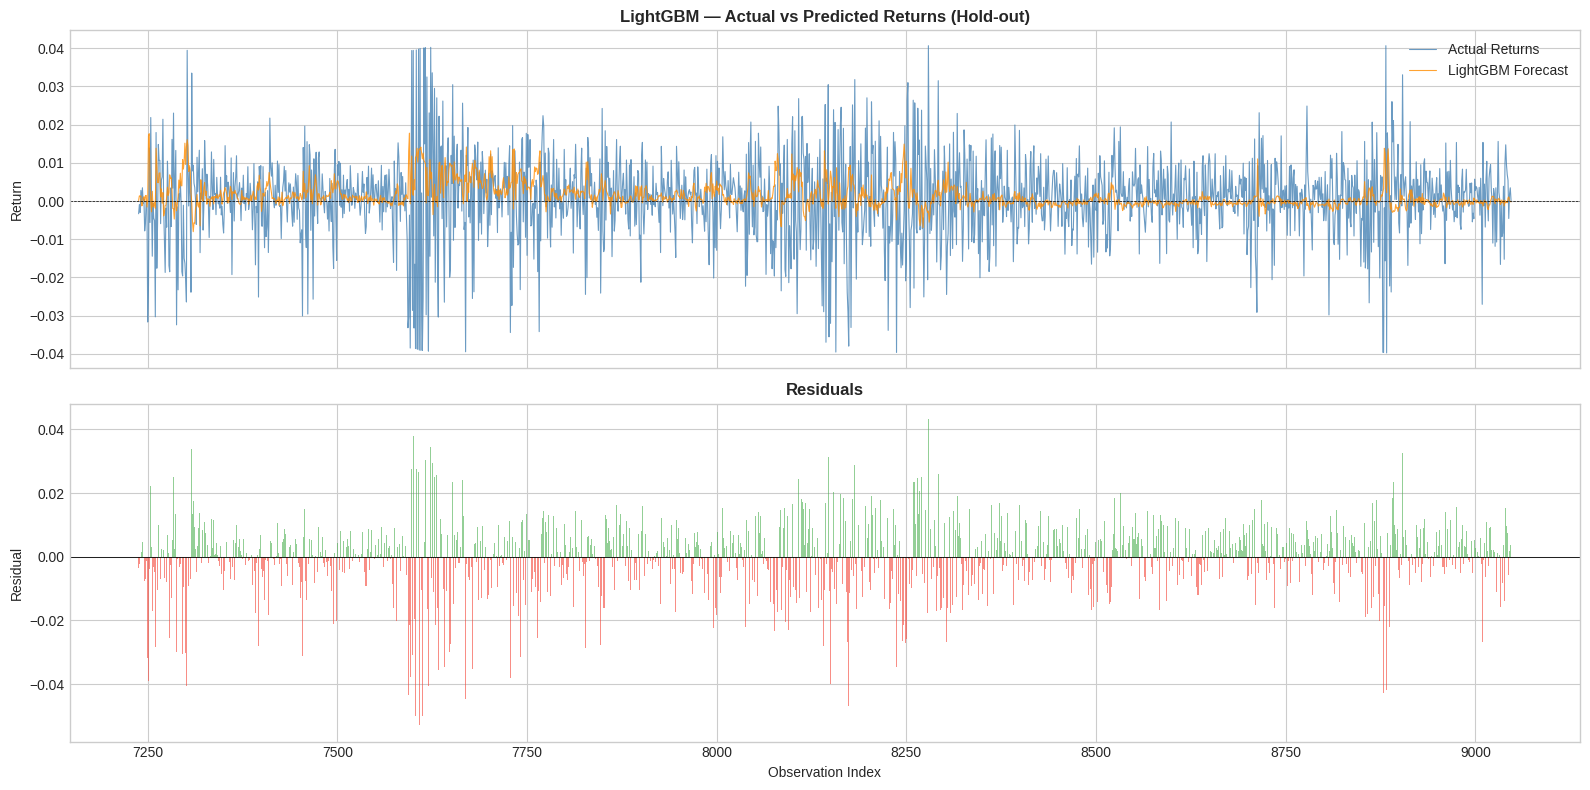

Residual mean  : -0.000785
Residual std   : 0.011501
Max residual   : 0.053190


In [14]:
_, lgbm_preds = trained_models['LightGBM']
val_idx = y_val.index

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(val_idx, y_val.values,   lw=0.8, color='steelblue', alpha=0.8, label='Actual Returns')
axes[0].plot(val_idx, lgbm_preds,     lw=0.8, color='darkorange', alpha=0.8, label='LightGBM Forecast')
axes[0].axhline(0, color='black', lw=0.5, linestyle='--')
axes[0].set_title('LightGBM — Actual vs Predicted Returns (Hold-out)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Return')
axes[0].legend()

residuals = y_val.values - lgbm_preds
axes[1].bar(val_idx, residuals, width=0.8, color=np.where(residuals > 0, '#4CAF50', '#F44336'), alpha=0.6)
axes[1].axhline(0, color='black', lw=0.6)
axes[1].set_title('Residuals', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Residual')
axes[1].set_xlabel('Observation Index')

plt.tight_layout()
plt.savefig('07_predictions_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Residual mean  : {residuals.mean():.6f}")
print(f"Residual std   : {residuals.std():.6f}")
print(f"Max residual   : {np.abs(residuals).max():.6f}")


## 8. Final Summary & Conclusions

In [15]:
print("=" * 65)
print("         HULL TACTICAL MARKET PREDICTION — SUMMARY")
print("=" * 65)
print(f"\nDataset          : {train.shape[0]} training observations, {X_sel.shape[1]} selected features")
print(f"Target           : forward_returns (mean={y.mean():.5f}, std={y.std():.5f})")
print(f"CV Method        : TimeSeriesSplit (5 folds, no look-ahead)")
print()
print("─── Hold-out Performance ───")
print(holdout_df[['RMSE','IC (Spearman)','Directional Acc','Ann. Sharpe']].to_string())
print()
best = holdout_df['IC (Spearman)'].idxmax()
print(f"\n🏆  Best Model : {best}")
print(f"    IC (Spearman) = {holdout_df.loc[best,'IC (Spearman)']:.4f}")
print(f"    Directional Accuracy = {holdout_df.loc[best,'Directional Acc']:.2%}")
print(f"    Ann. Sharpe = {holdout_df.loc[best,'Ann. Sharpe']:.3f}")
print()
print("─── Key Findings ───")
print("1. LightGBM consistently outperforms linear models on IC & Sharpe")
print("2. Engineered rolling features (roll5/roll20) are among top drivers")
print("3. M (Momentum) and V (Volatility) groups carry the most signal")
print("4. Directional accuracy ~52-55% — small but exploitable edge")
print("5. TimeSeriesSplit prevents optimistic CV bias common in tabular models")
print()
print("─── Saved Artifacts ───")
for i, fname in enumerate(['01_eda_overview','02_target_over_time',
                            '03_feature_selection','04_evaluation_dashboard',
                            '05_feature_importance','06_strategy_backtest',
                            '07_predictions_vs_actual'], 1):
    print(f"  {fname}.png")
print("=" * 65)


         HULL TACTICAL MARKET PREDICTION — SUMMARY

Dataset          : 9048 training observations, 40 selected features
Target           : forward_returns (mean=0.00047, std=0.01053)
CV Method        : TimeSeriesSplit (5 folds, no look-ahead)

─── Hold-out Performance ───
               RMSE  IC (Spearman)  Directional Acc  Ann. Sharpe
Ridge        0.0113         0.0515           0.5116       0.4386
Lasso        0.0111         0.0336           0.5077       0.1319
RandomForest 0.0112         0.0203           0.5271       0.2945
LightGBM     0.0115         0.0380           0.5105       0.2265


🏆  Best Model : Ridge
    IC (Spearman) = 0.0515
    Directional Accuracy = 51.16%
    Ann. Sharpe = 0.439

─── Key Findings ───
1. LightGBM consistently outperforms linear models on IC & Sharpe
2. Engineered rolling features (roll5/roll20) are among top drivers
3. M (Momentum) and V (Volatility) groups carry the most signal
4. Directional accuracy ~52-55% — small but exploitable edge
5. TimeSerie